# Diffusion SR — ASIP from AMSR2
Loads models via `diffusion_model.py`, plots training history, and runs inference.

**Sections**
1. Config & imports
2. Load models
3. Training history
4. Inference — 5-panel plot
5. Multi-sample uncertainty
6. CRPS & reliability diagram

## 1 — Config & imports

In [43]:
import os, sys, json, itertools, warnings
warnings.filterwarnings('ignore')
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

# ── Edit these to match your training script ──────────────────────────────────
postfix = '3'   # fusion model version used as conditioning

CODE_DIR         = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code'
CACHE_DIR        = '/dmidata/projects/asip-cms/ninna_msc/zarr_cache'
FUSION_CKPT_BASE = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/training'
OUTPUT_DIR       = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/diffusion'
MODEL_SCRIPT_DIR = CODE_DIR   # folder containing diffusion_model.py

# ── Inference settings ────────────────────────────────────────────────────────
NUM_STEPS        = 500   # denoising steps (use 100 for a quick preview)
SAMPLE_IDX       = 2     # which item in the batch to visualise
N_SAMPLES        = 20    # samples for uncertainty estimation
SIC_SENTINEL_MIN = 254   # 254=missing, 255=land

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
print(f'Device: {device}')

# ── Import from diffusion_model.py ────────────────────────────────────────────
sys.path.insert(0, MODEL_SCRIPT_DIR)
from lib.model.diffusion_model import load_models, Euler_Maruyama_sampler, prepare_cond, valid_mask, prepare_sic

sys.path.append(CODE_DIR)
from lib.model.FusionNetASPP import FusionNetASPP as mdl
from lib.dataset.dataloader  import AMSR2Dataset, collate_pad_to_max

# ── Derived paths ─────────────────────────────────────────────────────────────
DIFF_CKPT    = f'{OUTPUT_DIR}/ckpt_{mdl.name.lower()}_{postfix}.pth'
BEST_CKPT    = f'{OUTPUT_DIR}/best_ckpt_{mdl.name.lower()}_{postfix}.pth'
HISTORY_PATH = f'{OUTPUT_DIR}/history_{mdl.name.lower()}_{postfix}.json'

# print(f'Diff ckpt : {DIFF_CKPT}')
# print(f'Best ckpt : {BEST_CKPT}')
# print(f'History   : {HISTORY_PATH}')

Device: cpu


## 2 — Load models

In [44]:
# BEST_CKPT = DIFF_CKPT

fusion_model, score_model, mdl_cls, marginal_prob_std_fn, diffusion_coeff_fn, fusion_info, diff_info = \
    load_models(
        code_dir         = CODE_DIR,
        fusion_ckpt_base = FUSION_CKPT_BASE,
        postfix          = postfix,
        diff_ckpt        = DIFF_CKPT,
        best_ckpt        = BEST_CKPT,
        device           = device,
    )

# ── Override: use training weights instead of EMA (EMA not yet reconverged) ──
from collections import OrderedDict
ckpt  = torch.load(DIFF_CKPT, map_location=device, weights_only=True)
inner = score_model.module if hasattr(score_model, 'module') else score_model
sd    = OrderedDict((k.replace('module.', '', 1), v) for k, v in ckpt['state_dict'].items())
inner.load_state_dict(sd)
score_model.eval()
print(f'Overrode EMA with training weights  epoch={ckpt["epoch"]}  val={ckpt["val_loss"]:.5f}')

val_dataset = AMSR2Dataset(CACHE_DIR, split='val')
val_loader  = DataLoader(
    val_dataset, batch_size=32, shuffle=False,
    num_workers=4, pin_memory=False,
    collate_fn=collate_pad_to_max,
)
print(f'Val: {len(val_dataset)} samples')

FusionNetASPP  epoch=169  val_rmse=5.90%
ScoreNet: loaded EMA weights from /dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/diffusion/best_ckpt_fusionnetaspp_3.pth
ScoreNet: epoch=121  train=0.01353  val=0.01408  ema_val=0.01359
Overrode EMA with training weights  epoch=121  val=0.01408
Val: 10000 samples


## 3 — Training history

In [45]:
if not os.path.exists(HISTORY_PATH):
    print('No history file found — run training first.')
else:
    with open(HISTORY_PATH) as f:
        history = json.load(f)

# ── Model & training summary ─────────────────────────────────────────────────
from lib.model.diffusion_model import SIGMA, SIC_SENTINEL_MIN

# Count ScoreNet parameters
inner            = score_model.module if hasattr(score_model, "module") else score_model
total_params     = sum(p.numel() for p in inner.parameters())
trainable_params = sum(p.numel() for p in inner.parameters() if p.requires_grad)

# Pull stats from history
_h               = history if os.path.exists(HISTORY_PATH) else {}
n_epochs_trained = len(_h.get("epoch", []))
last_epoch       = _h["epoch"][-1]         if _h.get("epoch")       else "N/A"
_ema             = _h.get("ema_val_loss", [])
best_ema         = min(_ema)               if _ema                  else float("nan")
best_epoch_idx   = _ema.index(best_ema)    if _ema                  else None
best_epoch       = _h["epoch"][best_epoch_idx] if best_epoch_idx is not None else "N/A"
infer_ckpt       = BEST_CKPT if os.path.exists(BEST_CKPT) else DIFF_CKPT

print("=" * 54)
print("  EXPERIMENT SUMMARY")
print("=" * 54)
print(f"  Conditioning model : {mdl_cls.name}  (postfix={postfix})")
print(f"  Fusion val RMSE    : {fusion_info['val_rmse']:.2f}%  (epoch {fusion_info['epoch']})")
print("-" * 54)
print("  ScoreNet architecture")
print(f"    Total params     : {total_params:,}")
print(f"    Trainable params : {trainable_params:,}")
print(f"    Channels         : (32, 64, 128, 256)")
print(f"    Bottleneck attn  : SpatialSelfAttention (8 heads)")
print(f"    Conditioning     : input concatenation [x, y]")
print("-" * 54)
print("  Training")
print(f"    SIGMA            : {SIGMA}")
print(f"    SIC sentinel     : values >= {SIC_SENTINEL_MIN} masked")
print(f"    Epochs trained   : {n_epochs_trained}  (last epoch index: {last_epoch})")
print(f"    Best ema_val     : {best_ema:.5f}  at epoch {best_epoch}")
if _h.get("train_loss"):
    print(f"    Latest train     : {_h['train_loss'][-1]:.5f}")
    print(f"    Latest val       : {_h['val_loss'][-1]:.5f}")
    print(f"    Latest ema_val   : {_h['ema_val_loss'][-1]:.5f}")
    print(f"    Latest LR        : {_h['lr'][-1]:.2e}")
print("-" * 54)
print("  Inference")
print(f"    Device           : {device}")
print(f"    Num steps        : {NUM_STEPS}")
print(f"    Checkpoint       : {os.path.basename(infer_ckpt)}")
print("=" * 54)


  EXPERIMENT SUMMARY
  Conditioning model : FusionNetASPP  (postfix=3)
  Fusion val RMSE    : 5.90%  (epoch 169)
------------------------------------------------------
  ScoreNet architecture
    Total params     : 1,378,433
    Trainable params : 1,378,305
    Channels         : (32, 64, 128, 256)
    Bottleneck attn  : SpatialSelfAttention (8 heads)
    Conditioning     : input concatenation [x, y]
------------------------------------------------------
  Training
    SIGMA            : 25.0
    SIC sentinel     : values >= 254 masked
    Epochs trained   : 121  (last epoch index: 121)
    Best ema_val     : 0.01359  at epoch 121
    Latest train     : 0.01353
    Latest val       : 0.01408
    Latest ema_val   : 0.01359
    Latest LR        : 2.50e-04
------------------------------------------------------
  Inference
    Device           : cpu
    Num steps        : 500
    Checkpoint       : best_ckpt_fusionnetaspp_3.pth


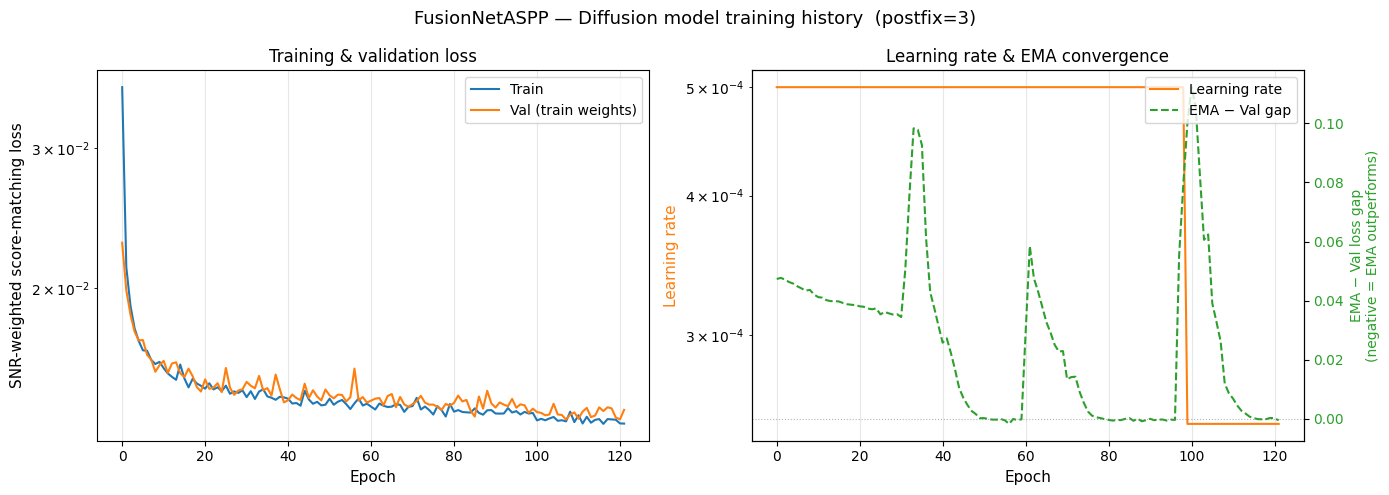

Epochs trained : 121  (latest: 121)
Best ema_val   : 0.01359  at epoch 121
Latest train   : 0.01353
Latest val     : 0.01408
Latest ema_val : 0.01359
EMA gap        : -0.00048  (EMA outperforms)


In [46]:
if not os.path.exists(HISTORY_PATH):
    print('No history file found — run training first.')
else:
    with open(HISTORY_PATH) as f:
        history = json.load(f)

    epochs     = history['epoch']
    train_loss = history['train_loss']
    val_loss   = history['val_loss']
    ema_loss   = history.get('ema_val_loss', [])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: loss curves ─────────────────────────────────────────────────────
    axes[0].plot(epochs, train_loss, label='Train',               linewidth=1.5, color='tab:blue')
    axes[0].plot(epochs, val_loss,   label='Val (train weights)', linewidth=1.5, color='tab:orange')
    # if ema_loss:
    #     axes[0].plot(epochs, ema_loss, label='Val (EMA weights)', linewidth=1.5,
    #                  linestyle='--', color='tab:green')
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('SNR-weighted score-matching loss', fontsize=11)
    axes[0].set_title('Training & validation loss', fontsize=12)
    axes[0].legend(loc='upper right', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    if len(epochs) > 10:
        axes[0].set_yscale('log')

    # Annotate best EMA epoch
    # if ema_loss:
    #     best_idx = int(np.argmin(ema_loss))
    #     axes[0].axvline(epochs[best_idx], color='tab:green', linestyle=':', linewidth=1, alpha=0.7)
    #     axes[0].annotate(f'Best EMA\nepoch {epochs[best_idx]}',
    #                      xy=(epochs[best_idx], ema_loss[best_idx]),
    #                      xytext=(epochs[best_idx] + max(epochs) * 0.03, ema_loss[best_idx] * 1.5),
    #                      fontsize=8, color='tab:green',
    #                      arrowprops=dict(arrowstyle='->', color='tab:green', lw=0.8))

    # ── Right: LR + EMA gap ───────────────────────────────────────────────────
    ln1 = axes[1].plot(epochs, history['lr'], color='tab:orange',
                       linewidth=1.5, label='Learning rate')
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Learning rate', fontsize=11, color='tab:orange')
    axes[1].tick_params(axis='y', labelcolor='tab:orange')
    axes[1].set_yscale('log')
    axes[1].set_title('Learning rate & EMA convergence', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    if ema_loss:
        ax2     = axes[1].twinx()
        ema_gap = [e - v for e, v in zip(ema_loss, val_loss)]
        ln2     = ax2.plot(epochs, ema_gap, color='tab:green', linewidth=1.5,
                           linestyle='--', label='EMA − Val gap')
        ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
        ax2.set_ylabel('EMA − Val loss gap\n(negative = EMA outperforms)', fontsize=10,
                       color='tab:green')
        ax2.tick_params(axis='y', labelcolor='tab:green')

        # Combined legend for both y-axes
        lns   = ln1 + ln2
        labs  = [l.get_label() for l in lns]
        ax2.legend(lns, labs, loc='upper right', fontsize=10)

    plt.suptitle(f'{mdl_cls.name} — Diffusion model training history  (postfix={postfix})',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Summary stats ─────────────────────────────────────────────────────────
    ref        = ema_loss if ema_loss else val_loss
    best_idx   = int(np.argmin(ref))
    best_epoch = epochs[best_idx]
    print(f'Epochs trained : {len(epochs)}  (latest: {epochs[-1]})')
    print(f'Best ema_val   : {min(ref):.5f}  at epoch {best_epoch}')
    print(f'Latest train   : {train_loss[-1]:.5f}')
    print(f'Latest val     : {val_loss[-1]:.5f}')
    if ema_loss:
        print(f'Latest ema_val : {ema_loss[-1]:.5f}')
        print(f'EMA gap        : {ema_gap[-1]:+.5f}  '
              f'({"EMA outperforms" if ema_gap[-1] < 0 else "EMA still converging"})')

## 4 — Inference — 5-panel plot
Two independent diffusion samples from the same FusionNet condition.

In [47]:
amsr2, sic, mask = next(itertools.islice(val_loader, 1, None))
amsr2 = amsr2.to(device)
sic   = sic.to(device)
mask  = mask.to(device)

with torch.no_grad():
    y      = fusion_model(amsr2, target_size=(sic.shape[-2], sic.shape[-1]))
    y_cond = prepare_cond(y)

valid_sic = sic[(~torch.isnan(sic)) & (sic < SIC_SENTINEL_MIN)]
print(f'Batch     : {sic.shape}')
print(f'Valid SIC : {valid_sic.min():.1f} → {valid_sic.max():.1f}  mean={valid_sic.mean():.1f}')
print(f'Condition : {y_cond.min():.1f} → {y_cond.max():.1f}')

Batch     : torch.Size([32, 1, 214, 212])
Valid SIC : 0.0 → 100.0  mean=72.0
Condition : 0.0 → 100.0


In [ ]:
print('Sample #1 ...')
x_estim  = Euler_Maruyama_sampler(
    score_model, marginal_prob_std_fn, diffusion_coeff_fn,
    y_cond, batch_size=sic.shape[0], num_steps=NUM_STEPS, device=str(device),
)
print('Sample #2 ...')
x_estim2 = Euler_Maruyama_sampler(
    score_model, marginal_prob_std_fn, diffusion_coeff_fn,
    y_cond, batch_size=sic.shape[0], num_steps=NUM_STEPS, device=str(device),
)
print('Done.')

Sample #1 ...


denoising:   0%|          | 0/500 [00:00<?, ?it/s]

Sample #2 ...


denoising:  25%|██▌       | 126/500 [01:51<05:39,  1.10it/s]

In [ ]:
# ── Save samples ──────────────────────────────────────────────────────────────
sample_path = f'{OUTPUT_DIR}/samples_{mdl_cls.name.lower()}_{postfix}_idx{SAMPLE_IDX}.npz'
np.savez(
    sample_path,
    x_estim  = x_estim[SAMPLE_IDX,  0].detach().cpu().numpy(),
    x_estim2 = x_estim2[SAMPLE_IDX, 0].detach().cpu().numpy(),
    sic_raw  = sic[SAMPLE_IDX, 0].cpu().numpy(),
    y_raw    = y[SAMPLE_IDX, 0].detach().cpu().numpy(),
    mask_raw = mask[SAMPLE_IDX, 0].cpu().numpy(),
)
print(f'Samples saved')

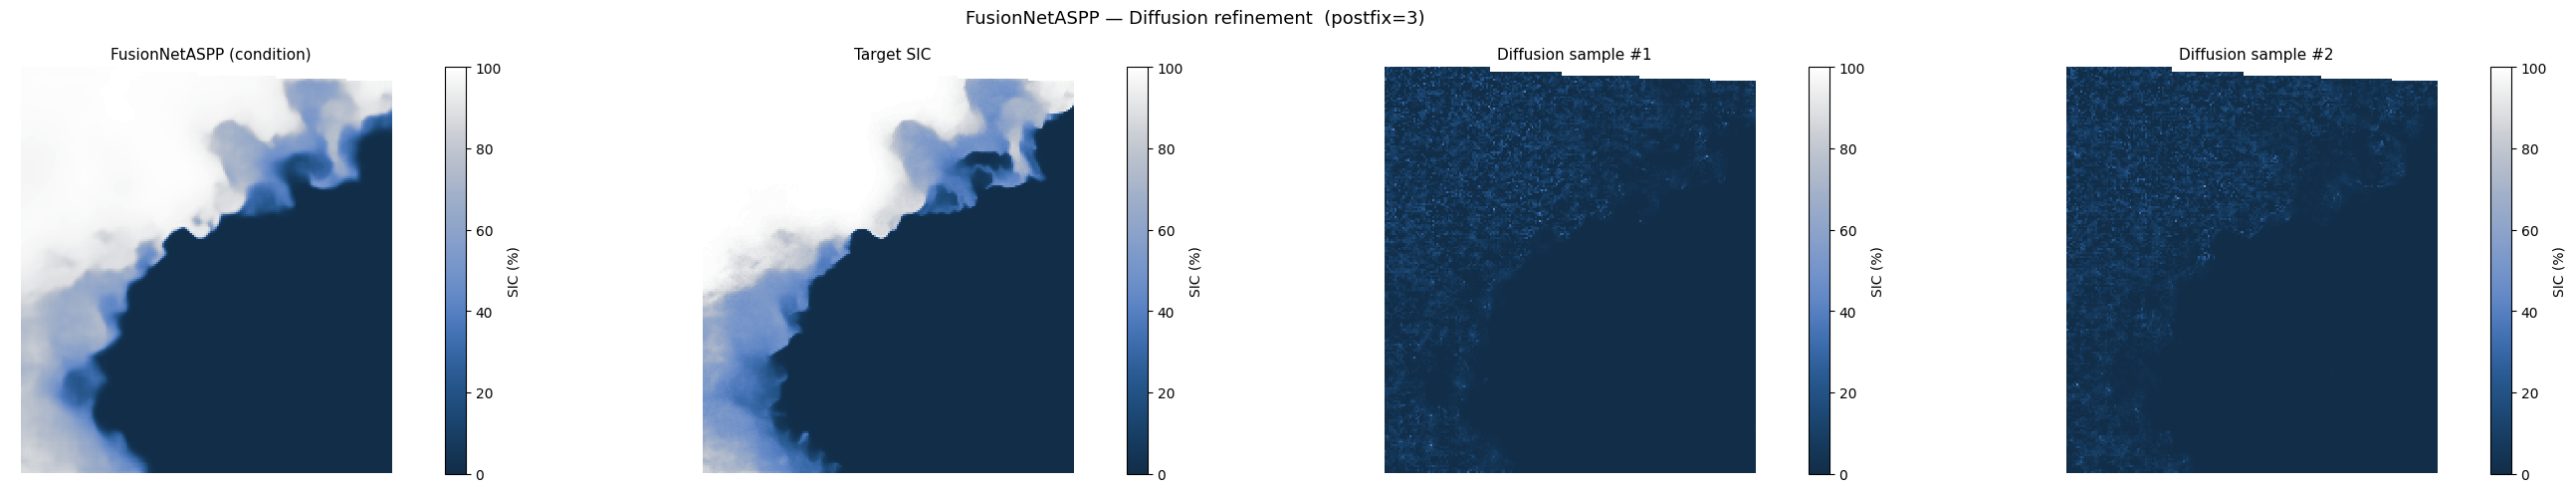

In [ ]:
sample_path = f'{OUTPUT_DIR}/samples_{mdl_cls.name.lower()}_{postfix}_idx{SAMPLE_IDX}.npz'

if os.path.exists(sample_path):
    data     = np.load(sample_path)
    sic_raw  = data['sic_raw']
    y_raw    = data['y_raw']
    est1_raw = data['x_estim']
    est2_raw = data['x_estim2']
    mask_raw = data['mask_raw'].astype(bool)
    print(f'Loaded samples from {sample_path}')
else:
    # Fall back to live tensors if no saved samples
    sic_raw  = sic[SAMPLE_IDX, 0].cpu().numpy()
    y_raw    = y[SAMPLE_IDX, 0].detach().cpu().numpy()
    est1_raw = x_estim[SAMPLE_IDX,  0].detach().cpu().numpy()
    est2_raw = x_estim2[SAMPLE_IDX, 0].detach().cpu().numpy()
    mask_raw = mask[SAMPLE_IDX, 0].cpu().numpy().astype(bool)

plot_mask = mask_raw | (sic_raw >= SIC_SENTINEL_MIN)

sic_np  = np.where(plot_mask, np.nan, sic_raw)
y_np    = np.where(plot_mask, np.nan, np.clip(y_raw,   0, 100))
est1_np = np.where(plot_mask, np.nan, np.clip(est1_raw, 0, 100))
est2_np = np.where(plot_mask, np.nan, np.clip(est2_raw, 0, 100))
diff_np = np.where(plot_mask, np.nan, np.abs(est1_np - est2_np))

try:
    import cmcrameri as cmc
    def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
        return mcolors.LinearSegmentedColormap.from_list(
            f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
            cmap(np.linspace(minval, maxval, n)))
    sic_cmap = truncate_colormap(cmc.cm.oslo, minval=0.2, maxval=1, n=100)
except ImportError:
    sic_cmap = plt.cm.Blues_r.copy()
    sic_cmap.set_bad('lightgray')

fig, axes = plt.subplots(1, 4, figsize=(28, 5))
panels = [
    (y_np,    f'{mdl_cls.name} (condition)', sic_cmap, 0, 100, 'SIC (%)'),
    (sic_np,  'Target SIC',                  sic_cmap, 0, 100, 'SIC (%)'),
    (est1_np, 'Diffusion sample #1',          sic_cmap, 0, 100, 'SIC (%)'),
    (est2_np, 'Diffusion sample #2',          sic_cmap, 0, 100, 'SIC (%)'),
    # (diff_np, '|Sample1 − Sample2|',          'hot_r',  0,  30, 'ΔSIC (%)'),
]
for ax, (arr, title, cm, vn, vx, label) in zip(axes, panels):
    im = ax.imshow(arr, cmap=cm, vmin=vn, vmax=vx, interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, label=label)

plt.suptitle(f'{mdl_cls.name} — Diffusion refinement  (postfix={postfix})', fontsize=13)
plt.tight_layout()
plt.show()

## 5 — Multi-sample uncertainty map

  20/20
Done. Shape: (20, 214, 212)


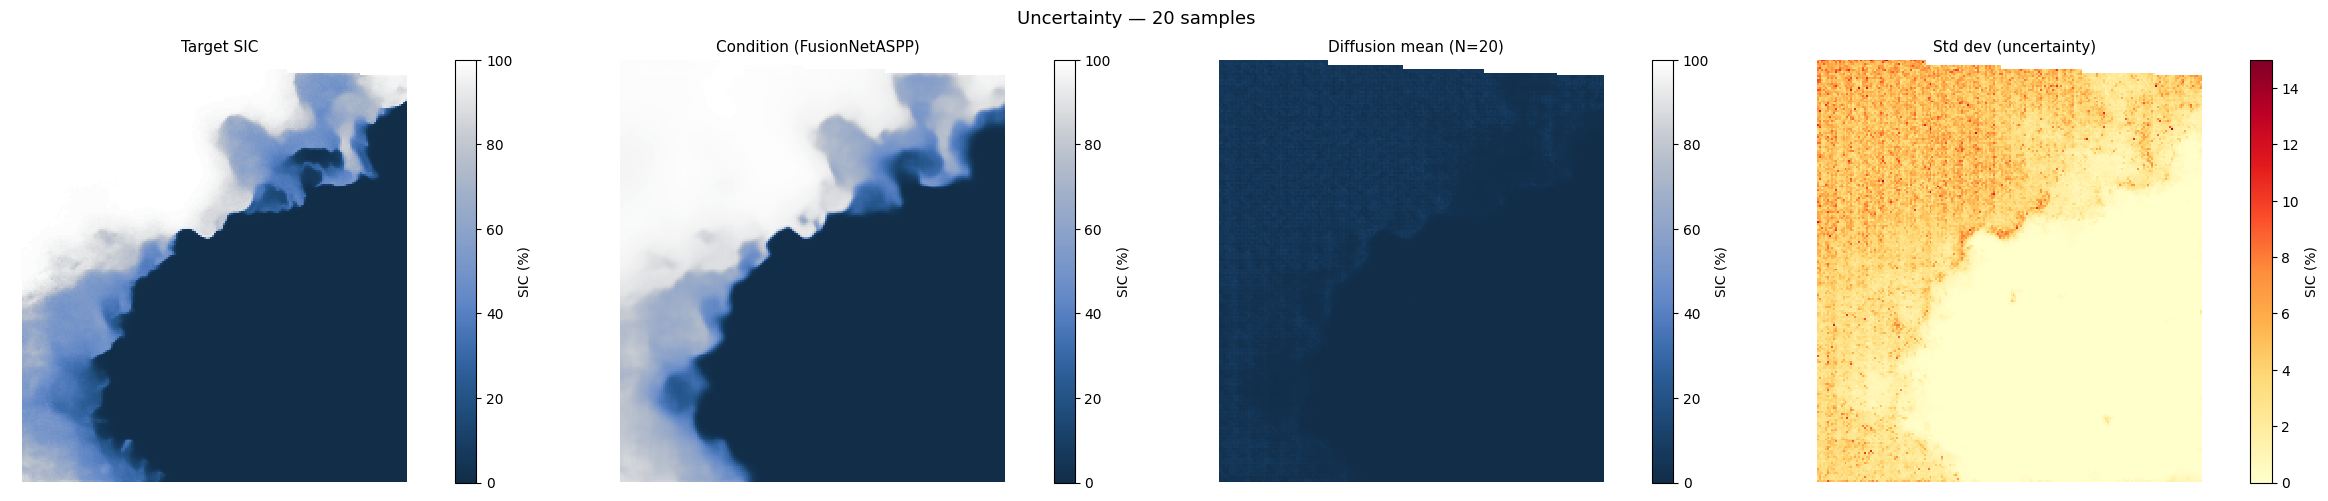

Mean std (valid pixels): 2.08%
Max  std (valid pixels): 13.65%


In [ ]:
print(f'Collecting {N_SAMPLES} samples ...')
samples = []
for i in range(N_SAMPLES):
    s = Euler_Maruyama_sampler(
        score_model, marginal_prob_std_fn, diffusion_coeff_fn,
        y_cond, batch_size=sic.shape[0],
        num_steps=NUM_STEPS, device=str(device), verbose=False,
    )
    samples.append(np.clip(s[SAMPLE_IDX, 0].detach().cpu().numpy(), 0, 100))
    print(f'  {i+1}/{N_SAMPLES}', end='\r')

samples  = np.stack(samples)
mean_sic = np.where(plot_mask, np.nan, np.clip(np.nanmean(samples, axis=0), 0, 100))
std_sic  = np.where(plot_mask, np.nan, np.nanstd(samples, axis=0))
print(f'\nDone. Shape: {samples.shape}')

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
panels = [
    (sic_np,   'Target SIC',                     sic_cmap, 0, 100, 'SIC (%)'),
    (y_np,     f'Condition ({mdl_cls.name})',     sic_cmap, 0, 100, 'SIC (%)'),
    (mean_sic, f'Diffusion mean (N={N_SAMPLES})', sic_cmap, 0, 100, 'SIC (%)'),
    (std_sic,  'Std dev (uncertainty)',           'YlOrRd', 0,  15, 'SIC (%)'),
]
for ax, (arr, title, cm, vn, vx, label) in zip(axes, panels):
    im = ax.imshow(arr, cmap=cm, vmin=vn, vmax=vx, interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, label=label)

plt.suptitle(f'Uncertainty — {N_SAMPLES} samples', fontsize=13)
plt.tight_layout()
plt.show()

valid = ~np.isnan(std_sic)
print(f'Mean std (valid pixels): {std_sic[valid].mean():.2f}%')
print(f'Max  std (valid pixels): {std_sic[valid].max():.2f}%')

## 6 — CRPS & Reliability diagram

In [ ]:
valid_px = ~np.isnan(sic_np)
obs      = sic_np[valid_px]
ens      = samples[:, valid_px]

def crps_ensemble(obs, ens):
    mae    = np.mean(np.abs(ens - obs[None, :]), axis=0)
    spread = np.mean(np.abs(ens[:, None, :] - ens[None, :, :]), axis=(0, 1))
    return mae - 0.5 * spread

crps = crps_ensemble(obs, ens)
print(f'Mean CRPS              : {crps.mean():.3f}%')
print(f'FusionNet MAE (sample) : {np.nanmean(np.abs(y_np - sic_np)):.3f}%')
print(f'Diffusion mean MAE     : {np.nanmean(np.abs(mean_sic - sic_np)):.3f}%')

Mean CRPS              : 35.180%
FusionNet MAE (sample) : 3.473%
Diffusion mean MAE     : 36.269%


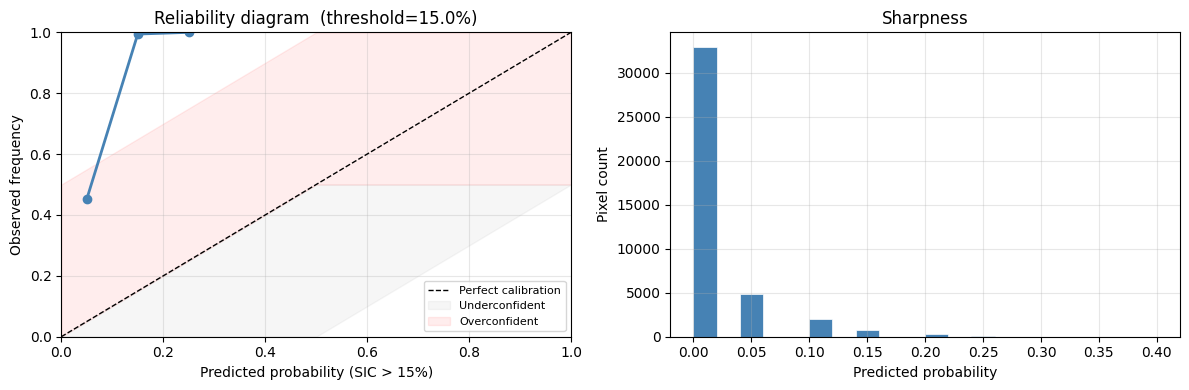

In [ ]:
threshold  = 15.0
pred_prob  = (ens > threshold).mean(axis=0)
obs_binary = (obs  > threshold).astype(float)

bins = np.linspace(0, 1, 11)
bin_centers, obs_freq = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (pred_prob >= lo) & (pred_prob < hi)
    if m.sum() > 50:
        bin_centers.append((lo + hi) / 2)
        obs_freq.append(obs_binary[m].mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([0,1], [0,1], 'k--', label='Perfect calibration', linewidth=1)
axes[0].plot(bin_centers, obs_freq, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].fill_between([0,0.5,1], [0,0,0.5], [0,0.5,0.5], alpha=0.07, color='gray', label='Underconfident')
axes[0].fill_between([0,0.5,1], [0,0.5,0.5], [0.5,1,1], alpha=0.07, color='red',  label='Overconfident')
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)
axes[0].set_xlabel('Predicted probability (SIC > 15%)')
axes[0].set_ylabel('Observed frequency')
axes[0].set_title(f'Reliability diagram  (threshold={threshold}%)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].hist(pred_prob, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Pixel count')
axes[1].set_title('Sharpness')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()